In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 
import insightface
from insightface.app import FaceAnalysis
from insightface.data import get_image as ins_get_image


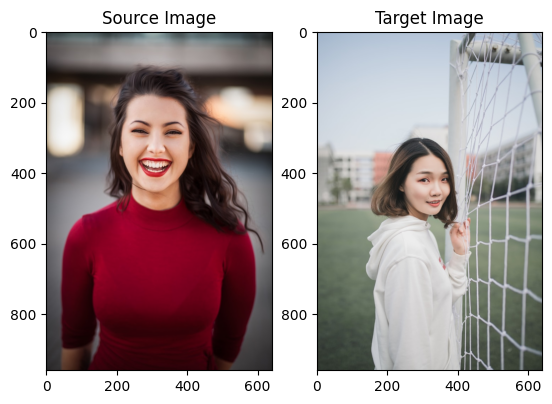

In [91]:
source_image = cv2.imread('images/model-1.jpg')
source_image = source_image[:,:,::-1]
target_image = cv2.imread('images/model-2.jpg')
target_image = target_image[:,:,::-1]

# load both image side by side, also give header on both of the image with name source and target
# also give a title on top of each image
plt.subplot(1, 2, 1)
plt.imshow(source_image)
plt.title('Source Image')
plt.subplot(1, 2, 2)
plt.imshow(target_image)
plt.title('Target Image')
plt.show()

In [98]:
import os
import sys
f = open(os.devnull, 'w')
sys.stdout = f

detector = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'], download=False, download_zip=False)
detector.prepare(ctx_id=0, det_size=(640, 640))

source_faces = detector.get(source_image)
target_faces = detector.get(target_image)

if len(source_faces) == 0 or len(target_faces) == 0:
    raise ValueError("No faces detected in the image")

target_face = target_faces[0]
source_face = source_faces[0]



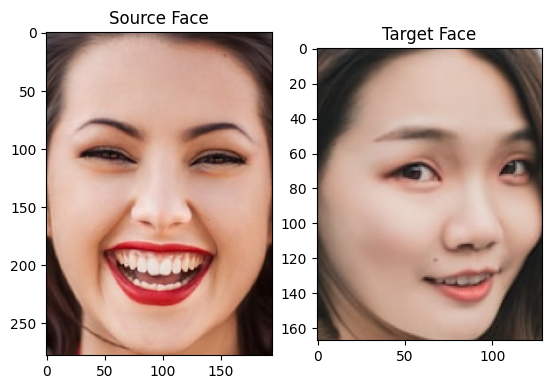

In [99]:
# display the detceted portion of the face
source_face_bbox = source_faces[0]['bbox']
source_face_bbox = [int(x) for x in source_face_bbox]
target_face_bbox = target_faces[0]['bbox']
target_face_bbox = [int(x) for x in target_face_bbox]

source_face_view = source_image[source_face_bbox[1]:source_face_bbox[3], source_face_bbox[0]:source_face_bbox[2]]
target_face_view = target_image[target_face_bbox[1]:target_face_bbox[3], target_face_bbox[0]:target_face_bbox[2]]
plt.subplot(1, 2, 1)
plt.imshow(source_face_view)
plt.title('Source Face')
plt.subplot(1, 2, 2)
plt.imshow(target_face_view)
plt.title('Target Face')
plt.show()


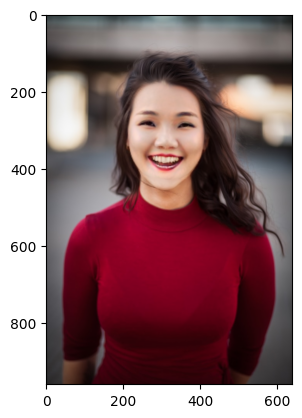

True

In [107]:
swapper = insightface.model_zoo.get_model('models/inswapper_128.onnx', download=False, download_onnx=False)

output = source_image.copy()
result = swapper.get(output, target_face=source_face, source_face=target_face, paste_back=True)
plt.imshow(result)
plt.show()

result = cv2.cvtColor(result, cv2.COLOR_RGB2BGR)
cv2.imwrite('result.jpg', result)
